In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('car_prices.csv')
df.head()

,car_id,mileage,selling_price
0,A001,126958,9734
1,A002,151867,8775
2,A003,136932,3928
3,A004,108694,12454
4,A005,124879,6634


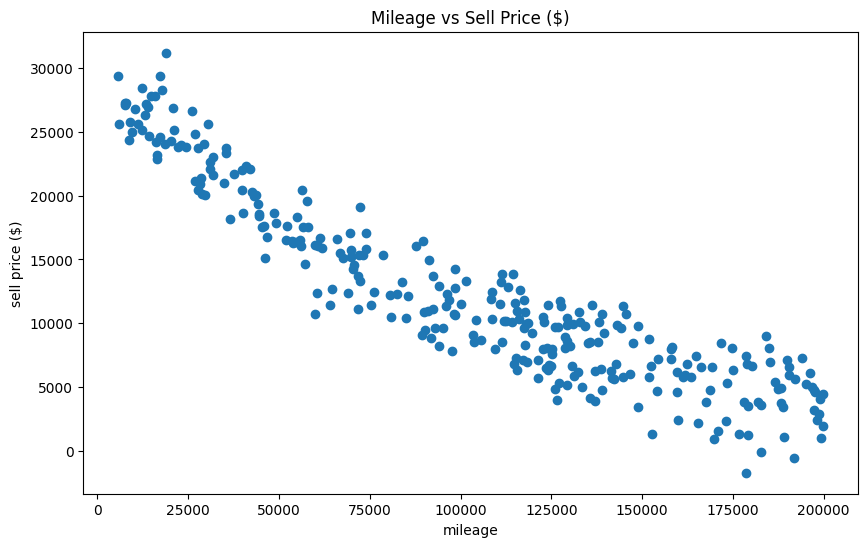

In [17]:
from matplotlib import  pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(df.mileage, df.selling_price)
plt.xlabel('mileage')
plt.ylabel('sell price ($)')
plt.title('Mileage vs Sell Price ($)')
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
X = df[["mileage"]]
y = df["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (240, 1) (240,)
Test shape: (60, 1) (60,)


## Detailed Model Training (Polynomial Regression)

This section trains and validates a polynomial regression model in a structured flow:

1. Split the data into train and test sets.
2. Generate polynomial features from mileage.
3. Fit a regression model using a pipeline.
4. Evaluate with MAE, RMSE, and $R^2$ on both train and test sets.
5. Plot the learned curve to interpret model behavior.

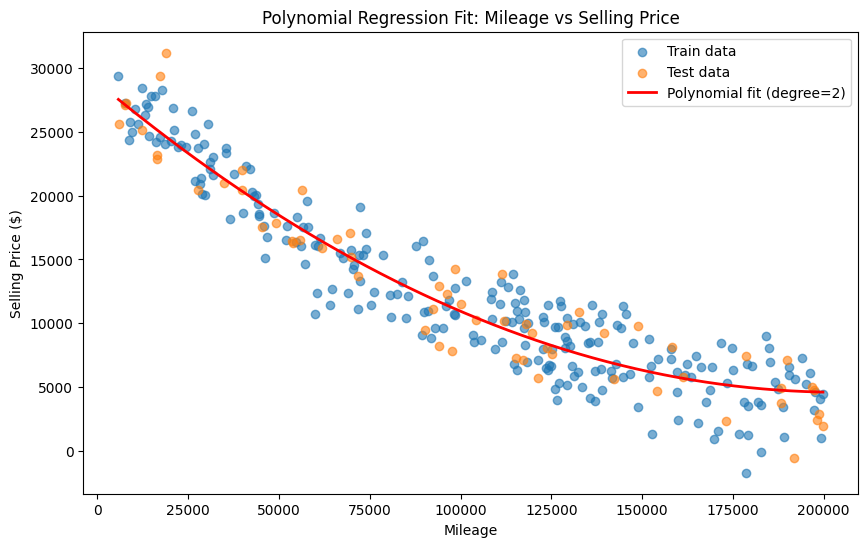

In [24]:
x_plot = pd.DataFrame(
    {"mileage": np.linspace(df["mileage"].min(), df["mileage"].max(), 200)}
)
y_plot = poly_model.predict(x_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_train["mileage"], y_train, alpha=0.6, label="Train data")
plt.scatter(X_test["mileage"], y_test, alpha=0.6, label="Test data")
plt.plot(x_plot["mileage"], y_plot, color="red", linewidth=2, label=f"Polynomial fit (degree={degree})")
plt.xlabel("Mileage")
plt.ylabel("Selling Price ($)")
plt.title("Polynomial Regression Fit: Mileage vs Selling Price")
plt.legend()
plt.show()

In [22]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

degree = 2

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
    ("regressor", LinearRegression())
])

poly_model.fit(X_train, y_train)

y_train_pred = poly_model.predict(X_train)
y_test_pred = poly_model.predict(X_test)

train_metrics = {
    "MAE": mean_absolute_error(y_train, y_train_pred),
    "RMSE": mean_squared_error(y_train, y_train_pred) ** 0.5,
    "R2": r2_score(y_train, y_train_pred),
}

test_metrics = {
    "MAE": mean_absolute_error(y_test, y_test_pred),
    "RMSE": mean_squared_error(y_test, y_test_pred) ** 0.5,
    "R2": r2_score(y_test, y_test_pred),
}

metrics_df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
metrics_df

,MAE,RMSE,R2
Train,1802.056786,2204.487031,0.905598
Test,1725.788648,2196.299351,0.915726
